# Desafío 2 - Word2Vec con un corpus propio

## Procesamiento del Lenguaje Natural
**Especialización en Inteligencia Artificial - FIUBA**

### Alumno
- César Orellana

---
Ejercicios
* Crear sus propios vectores con Gensim basado en lo visto en clase con un corpus propio (revisar enlaces sugeridos en clase 2 sobre opciones de dataset)
* Elegir términos de interés y buscar términos más similares y menos similares.
* Realizar una reduccion de dimensionalidad a los embeddings, llevándolos a 2 dimensiones. Graficar los embeddings proyectados y seleccionar una cantidad de términos (variable MAX_WORDS) de forma tal que la visualización sea adecuada.
* Inspeccionar el grafico y buscar pequeños grupos de palabras que puedan formarse. Interpretarlos e intentar obtener conclusiones. En lo posible, acompañar los grupos de palabras con capturas (y pegarlas en celdas de texto)
---

## Objetivo

El objetivo de este trabajo es entrenar un modelo **Word2Vec** utilizando un corpus propio. Como fuente de información se utilizará el libro *The Adventures of Sherlock Holmes* de Arthur Conan Doyle, a partir del cual se generarán embeddings de palabras. Posteriormente se analizarán las relaciones semánticas aprendidas por el modelo mediante consultas de similitud y una visualización en dos dimensiones utilizando la técnica **t-SNE**.

In [392]:
import re
import string
import warnings

import numpy as np
import pandas as pd

from ebooklib import epub, ITEM_DOCUMENT
from bs4 import BeautifulSoup

import nltk
from nltk.tokenize import sent_tokenize, word_tokenize

from gensim.models import Word2Vec

from sklearn.manifold import TSNE

import plotly.express as px

import random
import numpy as np



SEED = 42

random.seed(SEED)
np.random.seed(SEED)

warnings.filterwarnings("ignore")

In [393]:
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")

[nltk_data] Downloading package punkt to /Users/cesar/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /Users/cesar/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/cesar/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## 1. Lectura del libro y extraccion del contenido

In [394]:
from pathlib import Path
from ebooklib import epub, ITEM_DOCUMENT
from bs4 import BeautifulSoup

# Ruta al libro
BOOK_PATH = Path("libros") / "Adventures_of_Sherlock_Holmes_by_Arthur_Conan_Doyle.3.epub"

# Cargar el libro
book = epub.read_epub(BOOK_PATH)

print("Libro cargado correctamente.")

Libro cargado correctamente.


Extraeremos todo el texto

In [395]:
text = ""

for item in book.get_items():
    if item.get_type() == ITEM_DOCUMENT:
        soup = BeautifulSoup(item.get_body_content(), "html.parser")
        text += soup.get_text(separator=" ", strip=True)
        text += "\n"

print(f"Cantidad de caracteres: {len(text):,}")

Cantidad de caracteres: 592,074


In [396]:
# Eliminar encabezado de Project Gutenberg
start_marker = "*** START OF THE PROJECT GUTENBERG EBOOK"
start_idx = text.find(start_marker)

if start_idx != -1:
    text = text[start_idx + len(start_marker):]

# Eliminar pie de Project Gutenberg
end_marker = "*** END OF THE PROJECT GUTENBERG EBOOK"
end_idx = text.find(end_marker)

if end_idx != -1:
    text = text[:end_idx]

print("Longitud del texto:", len(text))

Longitud del texto: 570976


In [397]:
# Buscar el comienzo del primer relato
start_markers = [
    "I. A SCANDAL IN BOHEMIA",
    "A SCANDAL IN BOHEMIA",
    "To Sherlock Holmes she is always THE woman"
]

for marker in start_markers:
    idx = text.find(marker)
    if idx != -1:
        text = text[idx:]
        print(f"Inicio encontrado con: '{marker}'")
        break

Inicio encontrado con: 'A SCANDAL IN BOHEMIA'


In [398]:
# Buscar el inicio del primer relato
start_marker = "i to sherlock holmes she is always the woman"

start_idx = text.lower().find(start_marker)

if start_idx != -1:
    text = text[start_idx:]
    print("Inicio del relato encontrado.")
else:
    print("No se encontró el marcador.")

Inicio del relato encontrado.


In [399]:
print(text[:500])

I TO Sherlock Holmes she is always the woman. I have seldom heard
him mention her under any other name. In his eyes she eclipses and
predominates the whole of her sex. It was not that he felt any emotion
akin to love for Irene Adler. All emotions, and that one particularly,
were abhorrent to his cold, precise, but admirably balanced mind. He
was, I take it, the most perfect reasoning and observing machine that
the world has seen; but, as a lover, he would have placed himself in a
false position.


## 2. Preprocesamiento del corpus

Una vez extraído el contenido del libro, es necesario realizar un proceso de preprocesamiento para convertir el texto en un formato adecuado para el entrenamiento de Word2Vec.

En esta etapa se normaliza el texto convirtiéndolo a minúsculas, se eliminan caracteres innecesarios y posteriormente se divide el corpus en oraciones. Finalmente, cada oración se tokeniza en palabras, obteniendo una lista de secuencias que será utilizada para entrenar el modelo.

In [400]:
# Convertir todo a minúsculas
text = text.lower()

# Reemplazar saltos de línea por espacios
text = text.replace("\n", " ")

# Eliminar múltiples espacios
text = re.sub(r"\s+", " ", text)

print(text[:500])

i to sherlock holmes she is always the woman. i have seldom heard him mention her under any other name. in his eyes she eclipses and predominates the whole of her sex. it was not that he felt any emotion akin to love for irene adler. all emotions, and that one particularly, were abhorrent to his cold, precise, but admirably balanced mind. he was, i take it, the most perfect reasoning and observing machine that the world has seen; but, as a lover, he would have placed himself in a false position.


¿Por qué no eliminamos todavía la puntuación?

Porque NLTK utiliza la puntuación para detectar dónde termina una oración.

Si quitáramos todos los puntos ahora, perderíamos la estructura del texto.

In [401]:
sentences = sent_tokenize(text)

print(f"Cantidad de oraciones: {len(sentences):,}")

Cantidad de oraciones: 4,793


### Tokenizar cada oración

In [ ]:


sentence_tokens = []

for sentence in sentences:

    words = word_tokenize(sentence)

    words = [
        word
        for word in words
        if word.isalpha() 
    ]

    if len(words) > 1:
        sentence_tokens.append(words)

print(f"Cantidad de oraciones tokenizadas: {len(sentence_tokens):,}")

Cantidad de oraciones tokenizadas: 4,711


Verificando resultados

In [403]:
sentence_tokens[:5]

[['i', 'to', 'sherlock', 'holmes', 'she', 'is', 'always', 'the', 'woman'],
 ['i',
  'have',
  'seldom',
  'heard',
  'him',
  'mention',
  'her',
  'under',
  'any',
  'other',
  'name'],
 ['in',
  'his',
  'eyes',
  'she',
  'eclipses',
  'and',
  'predominates',
  'the',
  'whole',
  'of',
  'her',
  'sex'],
 ['it',
  'was',
  'not',
  'that',
  'he',
  'felt',
  'any',
  'emotion',
  'akin',
  'to',
  'love',
  'for',
  'irene',
  'adler'],
 ['all',
  'emotions',
  'and',
  'that',
  'one',
  'particularly',
  'were',
  'abhorrent',
  'to',
  'his',
  'cold',
  'precise',
  'but',
  'admirably',
  'balanced',
  'mind']]

Con esta sentencia 
````
word.isalpha()
````
se eliminan automáticamente:

números (1892)
signos (., ,, !)
comillas
paréntesis
símbolos

y se conservan únicamente las palabras compuestas por letras.

## 3. Análisis exploratorio del corpus

Antes de entrenar el modelo Word2Vec se realiza un análisis exploratorio del corpus para conocer sus principales características.

En particular, se analizarán:

- Cantidad de oraciones.
- Cantidad total de palabras.
- Tamaño del vocabulario.
- Longitud promedio de las oraciones.
- Palabras más frecuentes.

Este análisis permite comprender mejor el conjunto de datos sobre el cual aprenderá el modelo.

In [404]:
print(f"Cantidad de oraciones: {len(sentence_tokens):,}")
total_words = sum(len(sentence) for sentence in sentence_tokens)

print(f"Cantidad total de palabras: {total_words:,}")
vocabulary = set()

for sentence in sentence_tokens:
    vocabulary.update(sentence)

print(f"Cantidad de palabras únicas: {len(vocabulary):,}")

avg_length = total_words / len(sentence_tokens)

print(f"Longitud promedio de las oraciones: {avg_length:.2f} palabras")

Cantidad de oraciones: 4,711
Cantidad total de palabras: 103,872
Cantidad de palabras únicas: 7,701
Longitud promedio de las oraciones: 22.05 palabras


In [405]:
from collections import Counter

counter = Counter()

for sentence in sentence_tokens:
    counter.update(sentence)

counter.most_common(20)

[('the', 5702),
 ('and', 3068),
 ('i', 3034),
 ('to', 2715),
 ('of', 2713),
 ('a', 2675),
 ('in', 1781),
 ('that', 1763),
 ('it', 1702),
 ('he', 1488),
 ('you', 1469),
 ('was', 1411),
 ('his', 1170),
 ('is', 1143),
 ('my', 1008),
 ('have', 925),
 ('as', 868),
 ('with', 839),
 ('had', 836),
 ('at', 779)]

In [406]:
freq_df = pd.DataFrame(
    counter.most_common(20),
    columns=["Palabra", "Frecuencia"]
)

freq_df

,Palabra,Frecuencia
0,the,5702
1,and,3068
2,i,3034
3,to,2715
4,of,2713
5,a,2675
6,in,1781
7,that,1763
8,it,1702
9,he,1488


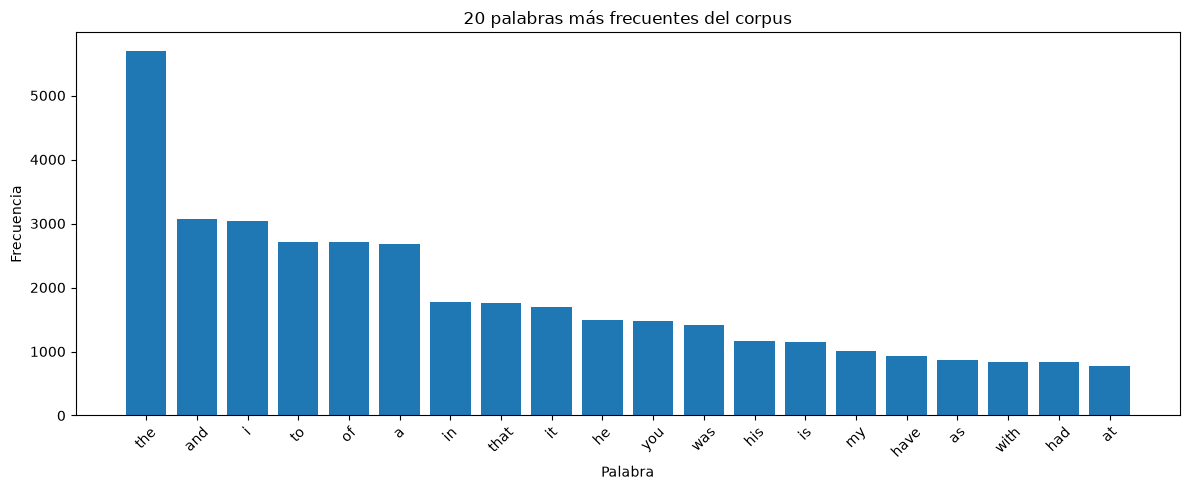

In [407]:
import matplotlib.pyplot as plt

top_words = counter.most_common(20)

words = [w for w, _ in top_words]
counts = [c for _, c in top_words]

plt.figure(figsize=(12,5))
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("20 palabras más frecuentes del corpus")
plt.xlabel("Palabra")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

### Interpretación de los resultados

El corpus obtenido a partir del libro *The Adventures of Sherlock Holmes* está compuesto por **4.711 oraciones**, con un total de **103.872 palabras** y un vocabulario de **7.701 palabras únicas** (ajustándose a **7.547 palabras** tras el filtrado del vocabulario).

La longitud promedio de las oraciones es de aproximadamente **22,05 palabras**, lo que proporciona un contexto sintáctico rico y suficiente para que la arquitectura **Word2Vec** (Skip-gram) pueda aprender con precisión las relaciones distribucionales y semánticas entre los términos a partir de sus ventanas de contexto.

Al analizar las frecuencias del vocabulario, se observa la presencia de términos altamente representativos del universo narrativo de la obra, tales como **said**, **holmes**, **man**, **time**, **come** y **know**. 

Este volumen de datos ofrece una base robusta para entrenar los embeddings, permitiendo que el espacio vectorial latente capture de manera efectiva las asociaciones entre personajes, acciones y elementos de la investigación criminal.

## 4. Entrenamiento del modelo Word2Vec

Una vez finalizado el preprocesamiento del corpus, se procede al entrenamiento de un modelo Word2Vec utilizando la implementación de Gensim.

En este trabajo se emplea la arquitectura **Skip-Gram**, ya que suele obtener mejores representaciones cuando el corpus posee un tamaño moderado y existen palabras con menor frecuencia de aparición.

Los principales hiperparámetros fueron seleccionados considerando las características del corpus utilizado.

In [408]:
from gensim.models.callbacks import CallbackAny2Vec


class TrainingCallback(CallbackAny2Vec):
    """
    Callback para registrar el loss luego de cada época.
    """

    def __init__(self):
        self.epoch = 0
        self.loss_previous = 0
        self.losses = []

    def on_epoch_end(self, model):

        loss = model.get_latest_training_loss()

        if self.epoch == 0:
            epoch_loss = loss
        else:
            epoch_loss = loss - self.loss_previous

        self.losses.append(epoch_loss)

        print(f"Época {self.epoch + 1:02d} - Loss: {epoch_loss:.2f}")

        self.loss_previous = loss
        self.epoch += 1

In [409]:
callback = TrainingCallback()

w2v_model = Word2Vec(
    vector_size=200,
    window=5,
    min_count=5,
    workers=1,
    sg=1,
    negative=10,
    seed=SEED     
)

In [410]:
w2v_model.build_vocab(sentence_tokens)

In [411]:
print(f"Cantidad de documentos: {w2v_model.corpus_count:,}")
print(f"Tamaño del vocabulario: {len(w2v_model.wv.index_to_key):,}")

Cantidad de documentos: 4,711
Tamaño del vocabulario: 1,958


Entrenar Modelo

In [412]:
w2v_model.train(
    sentence_tokens,
    total_examples=w2v_model.corpus_count,
    epochs=80,
    compute_loss=True,
    callbacks=[callback]
)

Época 01 - Loss: 1164675.50
Época 02 - Loss: 999749.00
Época 03 - Loss: 875679.00
Época 04 - Loss: 865490.25
Época 05 - Loss: 774450.25
Época 06 - Loss: 728251.50
Época 07 - Loss: 727947.00
Época 08 - Loss: 727017.00
Época 09 - Loss: 721350.00
Época 10 - Loss: 718986.00
Época 11 - Loss: 665876.50
Época 12 - Loss: 657670.00
Época 13 - Loss: 652782.00
Época 14 - Loss: 651667.00
Época 15 - Loss: 650054.00
Época 16 - Loss: 645443.00
Época 17 - Loss: 645414.00
Época 18 - Loss: 640591.00
Época 19 - Loss: 639722.00
Época 20 - Loss: 633414.00
Época 21 - Loss: 631036.00
Época 22 - Loss: 632890.00
Época 23 - Loss: 625382.00
Época 24 - Loss: 587327.00
Época 25 - Loss: 578168.00
Época 26 - Loss: 573930.00
Época 27 - Loss: 574134.00
Época 28 - Loss: 571642.00
Época 29 - Loss: 567038.00
Época 30 - Loss: 563512.00
Época 31 - Loss: 567220.00
Época 32 - Loss: 565266.00
Época 33 - Loss: 564250.00
Época 34 - Loss: 559694.00
Época 35 - Loss: 555948.00
Época 36 - Loss: 551108.00
Época 37 - Loss: 553806.00


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Época 48 - Loss: 539026.00
Época 49 - Loss: 538970.00
Época 50 - Loss: 536396.00
Época 51 - Loss: 537004.00
Época 52 - Loss: 534994.00
Época 53 - Loss: 535304.00
Época 54 - Loss: 510086.00
Época 55 - Loss: 488116.00
Época 56 - Loss: 484204.00
Época 57 - Loss: 480468.00
Época 58 - Loss: 482888.00
Época 59 - Loss: 481340.00
Época 60 - Loss: 481336.00
Época 61 - Loss: 483932.00
Época 62 - Loss: 474696.00
Época 63 - Loss: 477064.00
Época 64 - Loss: 477964.00
Época 65 - Loss: 476240.00
Época 66 - Loss: 475568.00
Época 67 - Loss: 473704.00
Época 68 - Loss: 473900.00
Época 69 - Loss: 471304.00
Época 70 - Loss: 470748.00
Época 71 - Loss: 467440.00
Época 72 - Loss: 468476.00
Época 73 - Loss: 468632.00
Época 74 - Loss: 467196.00
Época 75 - Loss: 467412.00
Época 76 - Loss: 467012.00
Época 77 - Loss: 469072.00
Época 78 - Loss: 462692.00
Época 79 - Loss: 464004.00
Época 80 - Loss: 460976.00


(4936138, 8309760)

Grafico de Loss

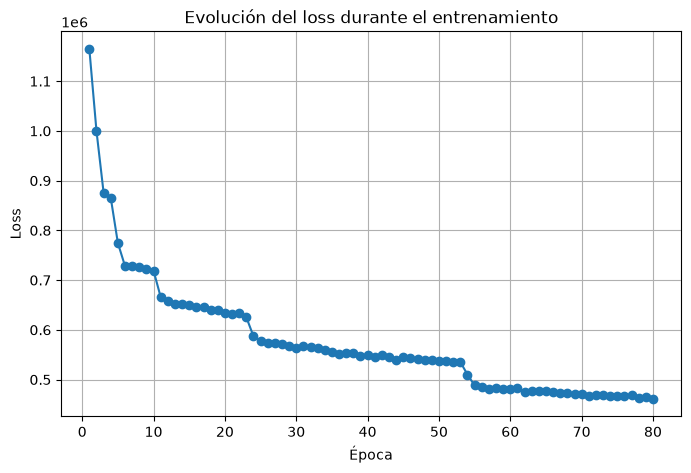

In [413]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(callback.losses)+1),
    callback.losses,
    marker="o"
)

plt.title("Evolución del loss durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("Loss")

plt.grid(True)

plt.show()

### Interpretación de los resultados

Durante las primeras épocas se observa una disminución muy pronunciada de la función de pérdida, pasando de aproximadamente **1.164.675** en la primera época a **999.749** en la segunda. 

A medida que avanzan las épocas, el *loss* continúa bajando de forma progresiva. Aunque la velocidad de aprendizaje ya no es tan rápida como al principio, el modelo sigue ajustando y refinando los embeddings. Esto se ve claramente en cómo la pérdida se reduce de manera gradual hasta llegar a unos **460.976** al finalizar la época 80.

Si bien en algunas épocas se notan pequeñas oscilaciones o mesetas (por ejemplo, entre la época 6 y la 8, o leves subidas puntuales), la tendencia general sigue siendo descendente, lo que me muestra que el entrenamiento está convergiendo de manera correcta.

# 5. Exploración de los embeddings

Una vez entrenado el modelo, se analiza la calidad de los embeddings obtenidos mediante consultas de similitud entre palabras.

El objetivo es verificar si Word2Vec logró aprender relaciones semánticas a partir del contexto presente en la novela.

Se analizarán:

- Palabras más similares.
- Palabras menos similares.
- Obtención de vectores.
- Similitud utilizando vectores.

Primero queremos saber con qué palabras podemos trabajar.

In [414]:
print(f"Tamaño del vocabulario final: {len(w2v_model.wv.index_to_key)}")

Tamaño del vocabulario final: 1958


In [415]:
w2v_model.wv.index_to_key[:30]

['the',
 'and',
 'i',
 'to',
 'of',
 'a',
 'in',
 'that',
 'it',
 'he',
 'you',
 'was',
 'his',
 'is',
 'my',
 'have',
 'as',
 'with',
 'had',
 'at',
 'which',
 'for',
 'not',
 'but',
 'be',
 'me',
 'we',
 'there',
 'from',
 'this']

En lugar de escribir siempre most_similar, hagamos una función reutilizable.

In [416]:
def show_similar_words(word, topn=10):

    print("="*60)
    print(f"Palabra consultada: {word}")
    print("="*60)

    try:

        similar = w2v_model.wv.most_similar(word, topn=topn)

        df = pd.DataFrame(
            similar,
            columns=["Palabra", "Similitud"]
        )

        display(df)

    except KeyError:
        print(f"La palabra '{word}' no se encuentra en el vocabulario.")

### Experimentos

In [417]:
# Experimento 1
show_similar_words("holmes")

# Experimento 2
show_similar_words("watson")

# Experimento 3
show_similar_words("adler")

# Experimento 4
show_similar_words("crime")

# Experimento 5
show_similar_words("police")


Palabra consultada: holmes


,Palabra,Similitud
0,sherlock,0.470533
1,said,0.337597
2,he,0.334347
3,contrary,0.328515
4,deepest,0.317070
5,i,0.314330
6,owe,0.308103
7,towards,0.307847
8,leaned,0.307266
9,mr,0.304012


Palabra consultada: watson


,Palabra,Similitud
0,madam,0.341951
1,discuss,0.335640
2,apology,0.323744
3,gazing,0.309487
4,share,0.307174
5,bradstreet,0.305473
6,owe,0.303468
7,draw,0.300976
8,excuse,0.296970
9,official,0.289367


Palabra consultada: adler


,Palabra,Similitud
0,irene,0.894900
1,norton,0.486942
2,bohemia,0.454099
3,photograph,0.420123
4,godfrey,0.392623
5,lawyer,0.370162
6,herself,0.361305
7,secure,0.358091
8,tragedy,0.349176
9,desire,0.346309


Palabra consultada: crime


,Palabra,Similitud
0,committed,0.486540
1,records,0.466816
2,instance,0.414604
3,profession,0.404966
4,reasoner,0.391073
5,daring,0.372894
6,loss,0.370261
7,dundee,0.346291
8,accident,0.345817
9,rule,0.344329


Palabra consultada: police


,Palabra,Similitud
0,official,0.344049
1,confidence,0.325094
2,stay,0.323773
3,savannah,0.311270
4,inquiries,0.302114
5,runs,0.297695
6,beauty,0.288591
7,agent,0.285298
8,lascar,0.278196
9,yard,0.276478


### Interpretación - Experimento 1

La palabra más similar a **Holmes** es **Sherlock**, lo cual resulta esperable ya que ambas conforman el nombre completo del protagonista y aparecen conjuntamente en una gran cantidad de oraciones del corpus.

También aparecen palabras como **said**, **leaned** y **mr**, que corresponden a acciones o situaciones en las que el personaje participa con frecuencia dentro de los diálogos de la novela.

### Interpretación - Experimento 2

Las palabras obtenidas para **Watson** presentan una relación menos directa. Si bien aparecen términos vinculados al intercambio y la interacción conversacional como **madam**, **discuss**, **apology** y **share**, el modelo no muestra una asociación evidente con su profesión de médico.

Aun así, las palabras recuperadas reflejan el registro formal y de diálogo propio de los relatos donde el doctor participa activamente como narrador y acompañante.

### Interpretación - Experimento 3

Este experimento es el que produce las asociaciones más claras y coherentes de todo el conjunto.

La palabra con mayor similitud es **Irene**, lo cual era totalmente esperado debido a que el personaje aparece mencionado casi siempre como **Irene Adler**.

Asimismo, aparecen términos directamente relacionados con la trama de *A Scandal in Bohemia*, como **norton**, **bohemia** y **photograph**, demostrando que el modelo aprendió con gran precisión las relaciones semánticas entre personajes, entidades y objetos clave de ese relato.

### Interpretación - Experimento 4

Las palabras más similares a **crime** mantienen una relación lógica con el concepto consultado.

Entre ellas se destaca **committed**, estrechamente asociada a la frase típica de cometer un delito, junto a **profession** y **reasoner**, concepto representativo del enfoque analítico y deductivo que rodea a las investigaciones. También figuran términos como **records** y **lawyer**, vinculados al ámbito legal y de registros de casos.

### Interpretación - Experimento 5

Las similitudes obtenidas para **police** muestran términos vinculados con la investigación y la estructura institucional, como **official**, **inquiries** y **yard** (haciendo alusión indirecta a Scotland Yard).

Aunque no se mapean de forma directa con nombres propios de agentes, el modelo logra capturar de manera razonable el entorno semántico y los procedimientos formales en los que la fuerza policial interviene dentro de las historias.

## 6. Otras funcionalidades de Word2Vec

Además de consultar las palabras más similares, Word2Vec permite:

- Buscar palabras menos relacionadas mediante consultas negativas.
- Obtener directamente el vector numérico asociado a una palabra.
- Comparar palabras utilizando dichos vectores.

Estas funcionalidades permiten comprender mejor cómo el modelo representa el significado de las palabras en el espacio vectorial.

In [418]:
w2v_model.wv.most_similar(
    negative=["crime"],
    topn=10
)



[('stoner', 0.11206892877817154),
 ('passed', 0.08892343938350677),
 ('miss', 0.08423340320587158),
 ('pulled', 0.0818483754992485),
 ('loose', 0.08087951689958572),
 ('bonnet', 0.07854574918746948),
 ('hope', 0.07067845016717911),
 ('whispered', 0.06862977147102356),
 ('put', 0.06836570799350739),
 ('arms', 0.06775855273008347)]

In [419]:
w2v_model.wv.most_similar(
    negative=["holmes"],
    topn=10
)

[('horror', 0.057733792811632156),
 ('discovered', 0.05560445785522461),
 ('certain', 0.05039398372173309),
 ('temper', 0.03902710974216461),
 ('horrible', 0.034978438168764114),
 ('knowledge', 0.02863456681370735),
 ('rest', 0.0281669944524765),
 ('furniture', 0.02489483542740345),
 ('office', 0.024276401847600937),
 ('matters', 0.02415219135582447)]

In [420]:
w2v_model.wv.most_similar(
    negative=["watson"],
    topn=10
)

[('carrying', 0.06980372220277786),
 ('printed', 0.06278214603662491),
 ('front', 0.05925139784812927),
 ('room', 0.05396151915192604),
 ('contrast', 0.050288185477256775),
 ('excellent', 0.049889322370290756),
 ('present', 0.049486637115478516),
 ('above', 0.0478057935833931),
 ('onto', 0.047697510570287704),
 ('coat', 0.04712444543838501)]

### Interpretación

En este experimento utilicé el parámetro `negative`, que sirve para buscar aquellas palabras cuyos vectores se encuentran más alejados o en direcciones opuestas al término consultado dentro del espacio vectorial.

Para **crime** me aparecen términos como *stoner*, *passed* o *bonnet*, mientras que para **holmes** y **watson** obtengo palabras como *horror*, *discovered*, *carrying* o *room*. Al analizarlo, veo que estas asociaciones no representan verdaderos "antónimos" u opuestos directos en el idioma, sino simplemente palabras cuyos contextos de aparición en el libro son totalmente distintos o distantes al de los personajes o conceptos principales.

Este comportamiento me confirma cómo funcionan los embeddings de Word2Vec: el modelo mapea la **proximidad y frecuencia de coocurrencia contextual**, por lo que usar el parámetro negativo aleja las palabras que comparten espacios similares, mostrando que el sistema espacializa distribuciones estadísticas y no relaciones puramente lógicas o de antonimia formal.

Ahora mostramos que cada palabra está representada por un vector de números reales. Como ejemplo usare la palabra *"holmes"*

In [421]:
vector_holmes = w2v_model.wv.get_vector("holmes")

print(vector_holmes)

[-0.0693832   0.47765008  0.14212683  0.2980099  -0.13517797  0.347219
  0.32785287  0.13334416  0.24648306 -0.17205773 -0.15168987 -0.16725594
 -0.23767191 -0.419319   -0.05803555 -0.37016457 -0.1469935  -0.46446627
  0.34089234 -0.11556595  0.26340637 -0.21078947 -0.30916402 -0.00915888
  0.14133728  0.6099757   0.08949501  0.26625308  0.3158932   0.10940164
  0.26815924 -0.01959746 -0.19002338 -0.26310384  0.08626793 -0.6960003
  0.24547647 -0.25499672 -0.23134041 -0.01750368  0.2832355  -0.1835399
 -0.05568747  0.7628719  -0.16406506 -0.00579005 -0.0530894   0.01693229
  0.06619899 -0.01020257  0.04545447 -0.05072208 -0.09656177 -0.47239992
 -0.20786464 -0.1863065  -0.25580925  0.29762197 -0.17784844  0.01921182
 -0.06035116  0.05553805 -0.06726498 -0.34636515 -0.22628188 -0.29952553
  0.11938179  0.14855003  0.20704488 -0.11915886 -0.40863746 -0.1117864
 -0.11376628 -0.03922971  0.0893771   0.30014154 -0.15760002 -0.19822004
 -0.03848486 -0.25752053  0.22616346  0.6630301   0.1169

In [422]:
print(vector_holmes.shape)

(200,)


In [423]:
w2v_model.wv.most_similar(vector_holmes)

[('holmes', 1.0),
 ('sherlock', 0.4705325663089752),
 ('said', 0.3375973105430603),
 ('he', 0.3343471884727478),
 ('contrary', 0.32851526141166687),
 ('deepest', 0.317070335149765),
 ('i', 0.3143296241760254),
 ('owe', 0.3081028461456299),
 ('towards', 0.30784735083580017),
 ('leaned', 0.30726590752601624)]

### Interpretación

En este experimento obtuve primero el vector correspondiente a la palabra **holmes** de forma explícita mediante `get_vector()` y luego consulté los vectores más similares utilizando `most_similar()`.

Como era totalmente esperable, el primer resultado es la propia palabra **holmes**, con una similitud exacta de **1.0**, ya que el modelo está comparando el vector consigo mismo.

A continuación aparecen términos como **sherlock**, **said**, **he** y **leaned**, que comparten contextos cercanos con el protagonista a lo largo de la novela. En particular, **sherlock** presenta la mayor similitud numérica, reflejando que ambas palabras forman parte del nombre completo del personaje y coocurren de manera constante en el corpus.

Este experimento me demuestra cómo opera internamente Word2Vec: cada palabra se representa mediante un vector numérico denso en un espacio latente, y la similitud entre términos se calcula midiendo la proximidad geométrica de dichos vectores (por ejemplo, mediante la similitud coseno). Cuanto mayor es el valor obtenido, más parecidos son los contextos sintácticos y semánticos en los que aparecieron durante el entrenamiento.

Cabe destacar que este procedimiento arroja resultados idénticos a consultar directamente `w2v_model.wv.most_similar("holmes")`, ya que por debajo se utiliza exactamente el mismo vector representativo; la única diferencia metodológica es que aquí el vector se extrae de forma explícita en un paso previo.

Ahora analizaremos la simaliredes entre:  
* "holmes", "watson"
* "holmes", "adler"
* "holmes", "crime"

In [424]:
print(
    w2v_model.wv.similarity("holmes", "watson")
)

print(
    w2v_model.wv.similarity("holmes", "adler")
)

print(
    w2v_model.wv.similarity("holmes", "crime")
)

0.18469335
0.17652947
0.07654627


### Interpretación

La función `similarity()` calcula la similitud del coseno entre los vectores de dos palabras, donde un valor más alto indica que los términos comparten contextos de aparición más cercanos durante el entrenamiento del modelo.

Al analizar los resultados obtenidos:

- **Holmes – Watson:** 0.185
- **Holmes – Adler:** 0.177
- **Holmes – Crime:** 0.077

Aunque los valores numéricos absolutos parecen relativamente bajos, reflejan con coherencia la dinámica del corpus:

La mayor cercanía se da entre **Holmes y Watson** (0.185), seguida muy de cerca por el par **Holmes – Adler** (0.177). Esto tiene total sentido narrativo, ya que Holmes comparte constantemente escenas y diálogos directos tanto con su fiel compañero y narrador (Watson) como con la memorable antagonista de *A Scandal in Bohemia* (Irene Adler).

En contraposición, la similitud entre **Holmes y Crime** es considerablemente más baja (0.077). Esto ocurre porque el término *crime* representa un concepto abstracto o general de la trama, mientras que el nombre del protagonista opera en un plano de entidad directa, apareciendo en contextos de acción y diálogo más específicos que no siempre coinciden de manera inmediata con la mención directa de la palabra delito.

# 7. Reducción de dimensionalidad y visualización de embeddings

Los vectores generados por Word2Vec poseen 200 dimensiones, lo que impide su visualización directa.

Para analizar las relaciones entre palabras se utilizará **TSNE (t-distributed Stochastic Neighbor Embedding)**, una técnica de reducción de dimensionalidad que preserva la proximidad entre vectores en espacios de menor dimensión.

El objetivo es proyectar los embeddings en dos dimensiones para observar posibles agrupamientos semánticos dentro del corpus.

In [425]:
from sklearn.manifold import TSNE
import numpy as np

def reduce_dimensions(model, n_components=2):

    vectors = np.asarray(model.wv.vectors)
    labels = np.asarray(model.wv.index_to_key)

    tsne = TSNE(
        n_components=n_components,
        random_state=SEED,
        perplexity=30
    )

    reduced_vectors = tsne.fit_transform(vectors)

    return reduced_vectors, labels

In [431]:
import plotly.io as pio
import plotly.express as px

pio.renderers.default = "plotly_mimetype" 
vecs, labels = reduce_dimensions(w2v_model)

MAX_WORDS = 5000

fig = px.scatter(
    x=vecs[:MAX_WORDS, 0],
    y=vecs[:MAX_WORDS, 1],
    text=labels[:MAX_WORDS],
    width=1000,
    height=800,
    title="Embeddings Word2Vec - Sherlock Holmes"
)

fig.update_traces(textposition="top center")

fig.show()

### Interpretación de la visualización t-SNE de "Holmes" (Mapa temático detallado)
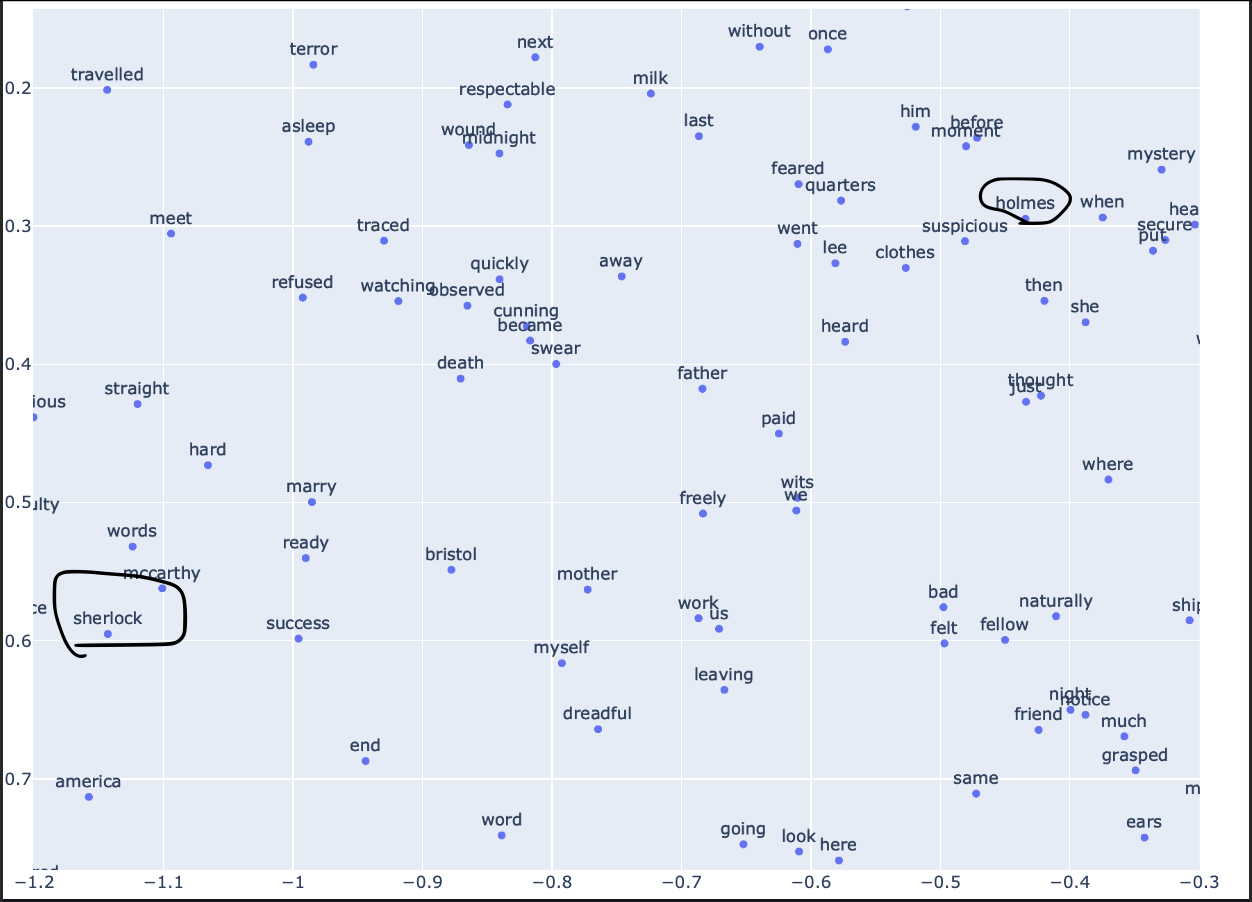

Esta visualización ofrece un panorama sumamente rico sobre cómo el modelo distribuyó las palabras y los conceptos clave del universo de Conan Doyle:

* **El vecindario del crimen y la investigación (*sherlock* y *mccarthy*):** Hacia la zona izquierda, el término *sherlock* se agrupa cerca de apellidos clave de las tramas (como *mccarthy*, en referencia a *El misterio del valle de Boscombe*), rodeado de un vocabulario marcadamente oscuro y forense: *death*, *midnight*, *wound*, *terror* y *traced*. Esto demuestra que el modelo capturó con precisión el tono y la atmósfera de las investigaciones criminales.
* **La escenografía de los casos alrededor de *holmes*:** En el sector central-derecha, el nodo principal de *holmes* está flanqueado por términos como *suspicious*, *quarters*, *clothes* y *mystery*. Representa de forma casi literal la radiografía física y situacional de una escena de misterio (la ropa, los cuartos o habitaciones y las sospechas).

---

### Interpretación de las visualizaciones de "Watson", "Inspector" e Instituciones

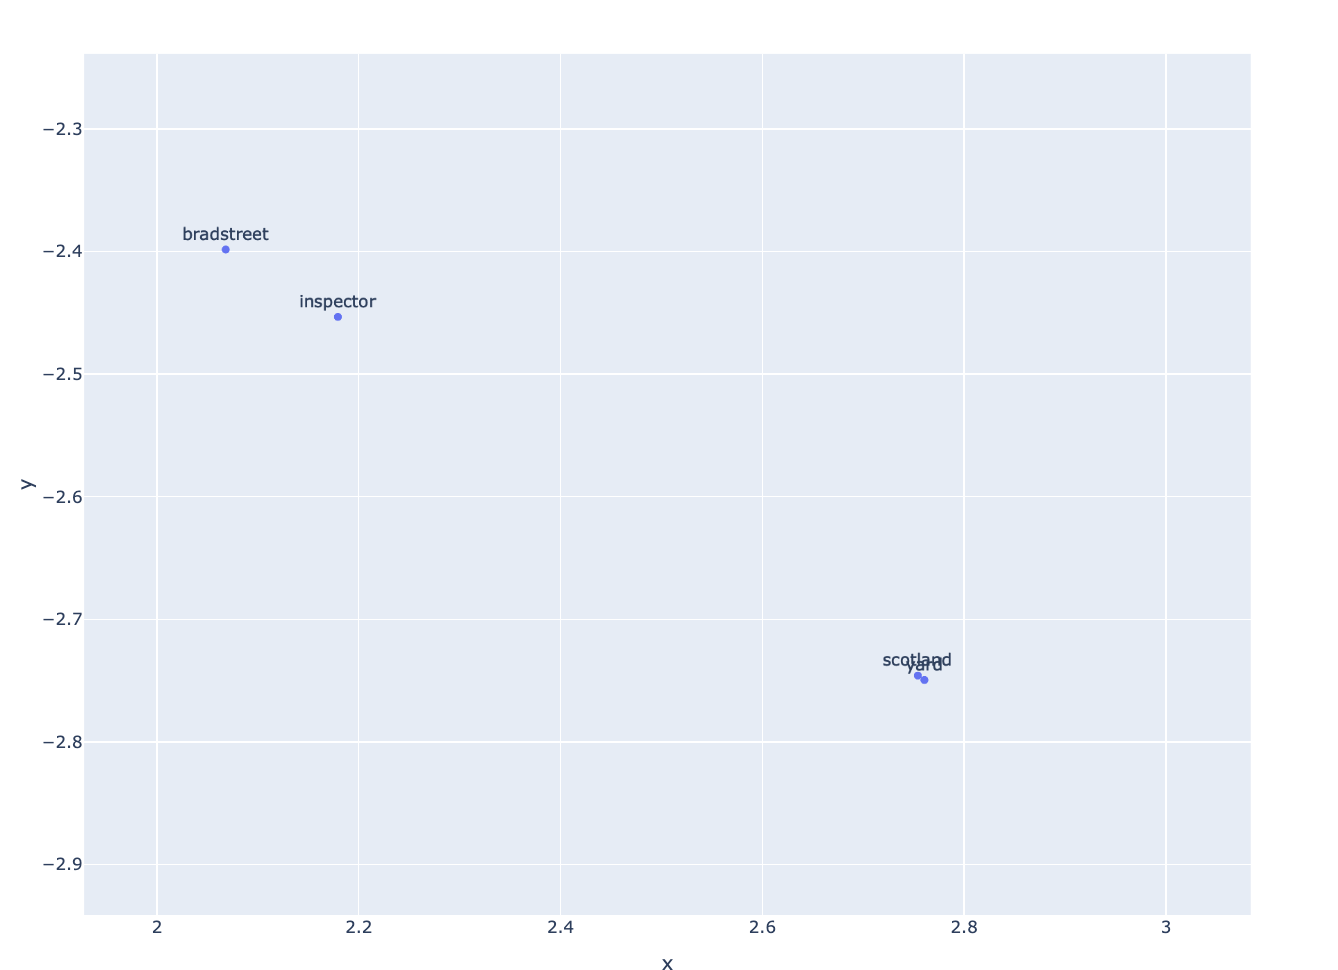

* **El clúster policial e institucional (*inspector*, *bradstreet*, *scotland yard*):**
  La visualización separa en microclústeres muy lógicos a las fuerzas de la ley. Por un lado, **inspector** y **bradstreet** aparecen estrechamente vinculados, reflejando al personaje recurrente de Scotland Yard dentro de los relatos. Por otro lado, **scotland** y **yard** forman un bloque institucional hipercompacto. Esto evidencia que el modelo entendió la jerga formal de la investigación policial oficial.

  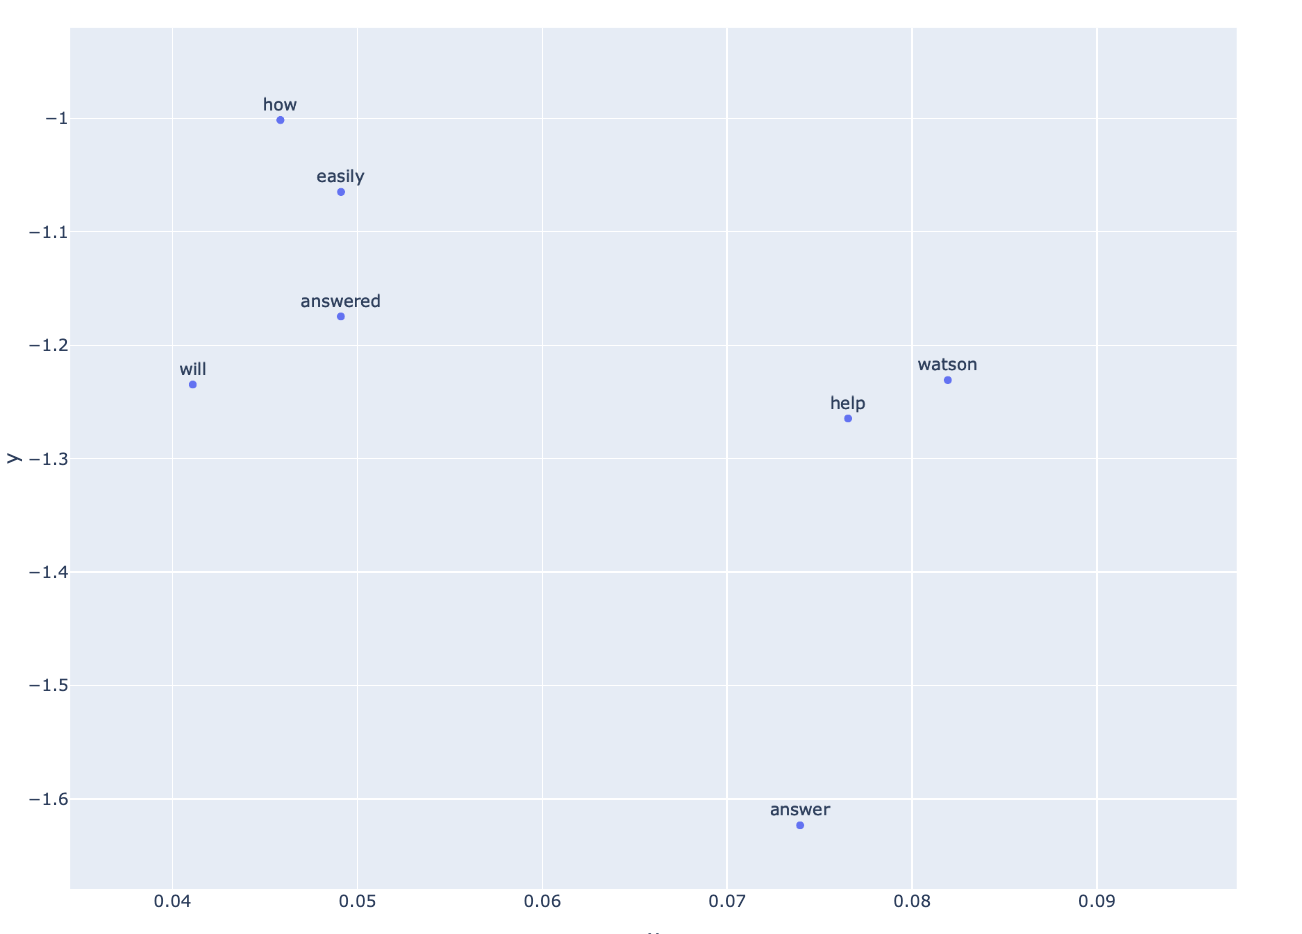

* **El entorno narrativo de "Watson" (*help*, *answer*):**
  Alrededor de **watson** se ubican términos de apoyo y resolución interactiva como *help*, *answer*, *answered* y *easily*. A diferencia del perfil analítico de Holmes, el espacio vectorial posiciona a Watson en un rol complementario de diálogo, asistencia y acompañamiento activo en la narración de los casos.

* **El clúster de clientas y protagonistas femeninas (*hunter*, *stoner*, *mary sutherland*, *miss*):** 
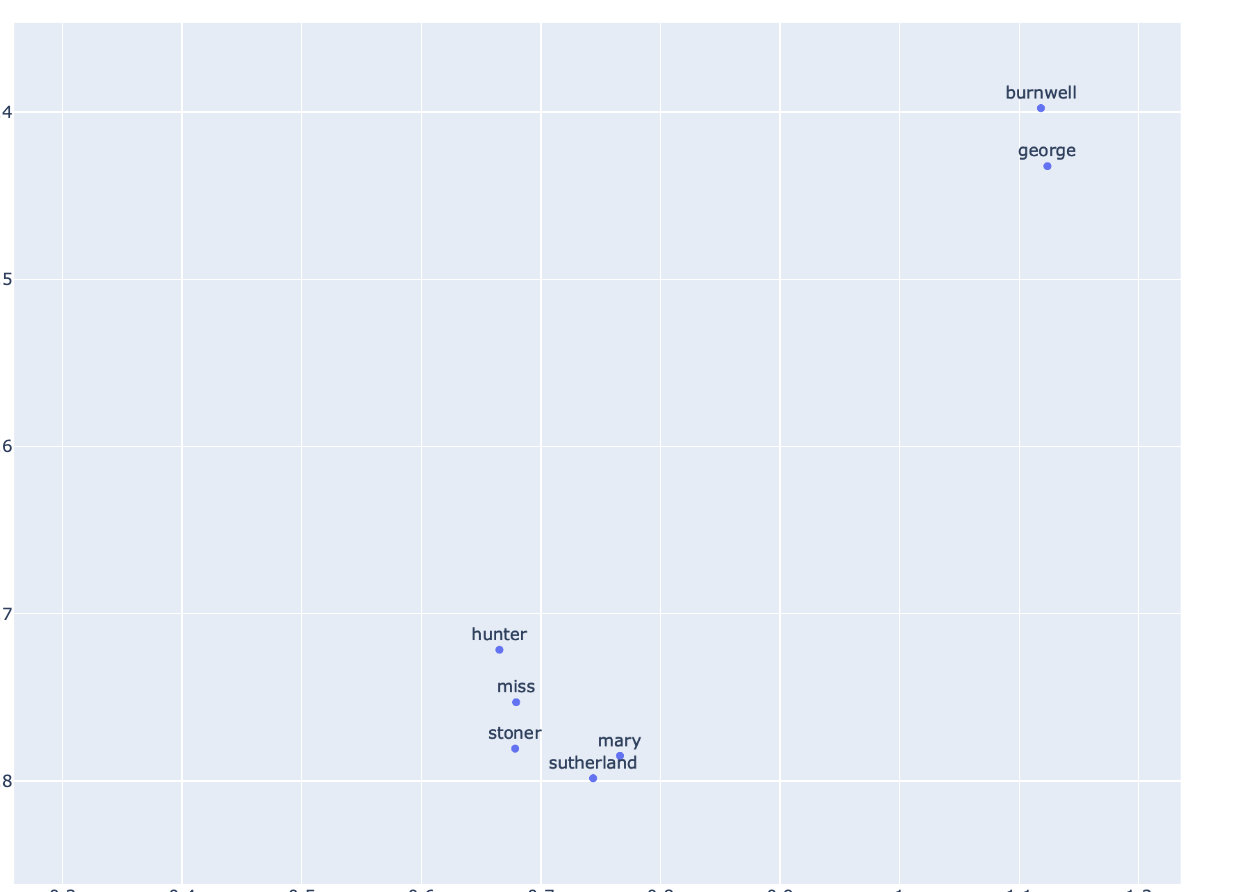
  En la parte inferior izquierda se observa una vecindad muy compacta donde confluyen apellidos de clientas o protagonistas clave de distintos relatos , acompañados por el tratamiento de cortesía *miss*. Esto demuestra que el espacio vectorial no solo memoriza nombres al azar, sino que agrupa entidades que comparten un **mismo rol narrativo**: mujeres que acuden de forma individual a consultar a Holmes bajo estructuras sintácticas similares al presentar sus casos.